 Description
 # 🎓 Student Academic Performance Prediction
### Implementation of: "Evaluation of Machine Learning Models in Student Academic Performance Prediction"
**Dataset:** xAPI-Edu-Data (SAPData) — Kalboard 360 LMS | 480 records, 16 features  
**Models:** MLP, SVM, k-NN, Logistic Regression, Naive Bayes, Decision Tree  
**Evaluation:** Repeated Hold-Out (RHO) + 10-fold Cross Validation  
**Extra:** SHAP Explainability on best model

In [1]:
# Install SHAP
!pip install shap --quiet

In [3]:
!pip install --upgrade typing_extensions shap --quiet

In [4]:
import shap
import pkg_resources

print("shap:", pkg_resources.get_distribution("shap").version)
print("typing_extensions:", pkg_resources.get_distribution("typing_extensions").version)

shap: 0.49.1
typing_extensions: 4.15.0


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)
from sklearn.feature_selection import chi2, SelectKBest
from scipy.stats import f_oneway

# Models
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

In [6]:
# Load & Inspect Dataset
df = pd.read_csv('xAPI-Edu-Data.csv')
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nClass Distribution:")
print(df['Class'].value_counts())
df.head()

Shape: (480, 17)

Column Names:
 ['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']

Class Distribution:
M    211
H    142
L    127
Name: Class, dtype: int64


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


EDA 
## 📊 Exploratory Data Analysis (EDA)
The dataset contains:
- **Demographic features** — gender, nationality, place of birth
- **Academic features** — grade, stage, section, topic, semester
- **Behavioral features** — raised hands, visited resources, announcements viewed, discussion
- **Parent features** — parent answering survey, parent school satisfaction, student absence days
- **Target** — Class (L = Low, M = Middle, H = High)

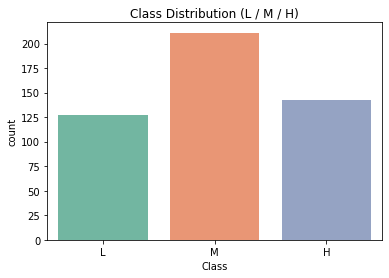

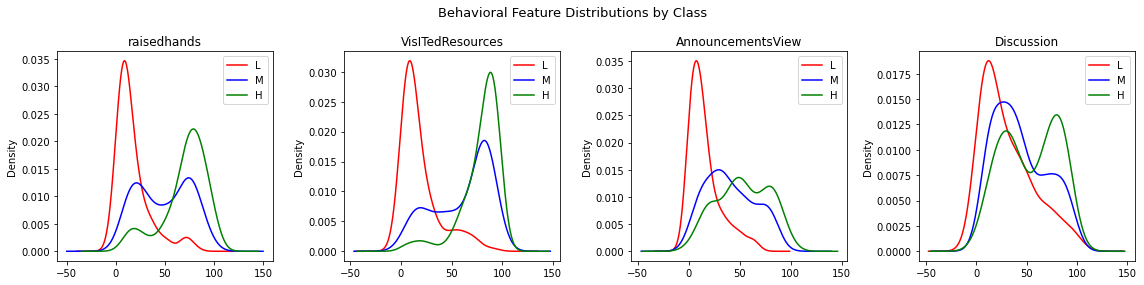

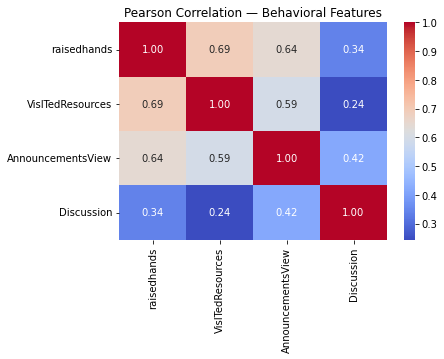

In [7]:
# EDA Visualizations
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Set2', order=['L','M','H'])
plt.title('Class Distribution (L / M / H)')
plt.show()

# Behavioral features distribution
behavioral = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, behavioral):
    for cls, color in zip(['L','M','H'], ['red','blue','green']):
        subset = df[df['Class'] == cls][col]
        subset.plot(kind='kde', ax=ax, label=cls, color=color)
    ax.set_title(col)
    ax.legend()
plt.suptitle('Behavioral Feature Distributions by Class', fontsize=13)
plt.tight_layout()
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(6,4))
sns.heatmap(df[behavioral].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation — Behavioral Features')
plt.show()

In [8]:
# Label Encoding
df_encoded = df.copy()
le = LabelEncoder()

# Encode all object columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Encode target: L=-1, M=0, H=+1 (as per paper)
target_map = {'L': -1, 'M': 0, 'H': 1}
df_encoded['Class'] = df['Class'].map(target_map)

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.head()

Encoded dataset shape: (480, 17)


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,4,4,2,1,0,7,0,0,15,16,2,20,1,1,1,0
1,1,4,4,2,1,0,7,0,0,20,20,3,25,1,1,1,0
2,1,4,4,2,1,0,7,0,0,10,7,0,30,0,0,0,-1
3,1,4,4,2,1,0,7,0,0,30,25,5,35,0,0,0,-1
4,1,4,4,2,1,0,7,0,0,40,50,12,50,0,0,0,0


In [9]:
# Feature Protocols (as per paper)
# Separate features and target
X_all = df_encoded.drop('Class', axis=1)
y     = df_encoded['Class']

# WBF — All features (With Behavioral Features)
behavioral_cols = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']
X_WBF  = X_all.copy()

# WOBF — All features EXCEPT behavioral
X_WOBF = X_all.drop(columns=behavioral_cols)

# FS — Feature Selection using Chi-squared (categorical) + EDA (numerical)
# Remove low-ranked categorical features based on paper: SectionID, StageID, GradeID, Semester
drop_cols = ['SectionID', 'StageID', 'GradeID', 'Semester']
# Only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in X_all.columns]
X_FS = X_all.drop(columns=drop_cols)

print("WBF features :", X_WBF.shape[1])
print("WOBF features:", X_WOBF.shape[1])
print("FS features  :", X_FS.shape[1])

WBF features : 16
WOBF features: 12
FS features  : 12


In [10]:
# Define Models with Optimal Hyperparameters
models = {
    'MLPC': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32, 16, 8),
        activation='relu',
        batch_size=100,
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42
    ),
    'SVM': SVC(
        kernel='linear', C=1,
        decision_function_shape='ovo',
        random_state=42
    ),
    'k-NN': KNeighborsClassifier(
        n_neighbors=15, p=1  # Manhattan distance
    ),
    'LR': LogisticRegression(
        penalty='l2', C=0.1,
        multi_class='ovr',
        max_iter=1000,
        random_state=42
    ),
    'NB': MultinomialNB(alpha=1),
    'DT': DecisionTreeClassifier(
        criterion='gini',
        splitter='random',
        max_depth=6,
        min_samples_split=4,
        min_samples_leaf=4,
        random_state=42
    )
}

In [11]:
# Evaluation Helper Functions
def evaluate_rho(model, X, y, n_repeats=100, test_size=0.1, scale=True, use_nb=False):
    """Repeated Hold-Out Validation (90:10 split, 100 times)"""
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=n_repeats,
                                  test_size=test_size,
                                  random_state=42)
    accs = []
    for train_idx, test_idx in sss.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        if scale and not use_nb:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        
        # NB needs non-negative values
        if use_nb:
            from sklearn.preprocessing import MinMaxScaler
            sc = MinMaxScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        
        model.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_te, model.predict(X_te)))
    
    return np.mean(accs), np.max(accs), np.std(accs)


def evaluate_kfold(model, X, y, n_splits=10, n_repeats=10, scale=True, use_nb=False):
    """Repeated Stratified K-Fold Cross Validation"""
    from sklearn.model_selection import RepeatedStratifiedKFold
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, MinMaxScaler
    
    rkf = RepeatedStratifiedKFold(n_splits=n_splits,
                                   n_repeats=n_repeats,
                                   random_state=42)
    accs = []
    for train_idx, test_idx in rkf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        if scale and not use_nb:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        if use_nb:
            sc = MinMaxScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        
        model.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_te, model.predict(X_te)))
    
    return np.mean(accs), np.max(accs), np.std(accs)

In [12]:
X_np = X_FS.values
y_np = y.values

print("=" * 60)
print("REPEATED HOLD-OUT VALIDATION — FS Protocol (n=20)")
print("=" * 60)

rho_results = {}
for name, model in models.items():
    print(f"  Running {name}...", end=" ")
    use_nb = (name == 'NB')
    avg, mx, std = evaluate_rho(model, X_np, y_np, 
                                 n_repeats=20, 
                                 use_nb=use_nb)
    rho_results[name] = {'Avg': avg*100, 'Max': mx*100, 'Std': std*100}
    print(f"Done → Avg: {avg*100:.2f}%  Max: {mx*100:.2f}%  Std: {std*100:.2f}%")

REPEATED HOLD-OUT VALIDATION — FS Protocol (n=20)
  Running MLPC... Done → Avg: 78.23%  Max: 87.50%  Std: 5.76%
  Running SVM... Done → Avg: 72.29%  Max: 81.25%  Std: 4.66%
  Running k-NN... Done → Avg: 71.25%  Max: 89.58%  Std: 6.90%
  Running LR... Done → Avg: 70.94%  Max: 81.25%  Std: 4.59%
  Running NB... Done → Avg: 65.31%  Max: 75.00%  Std: 5.16%
  Running DT... Done → Avg: 70.62%  Max: 81.25%  Std: 4.88%


In [13]:
X_np = X_FS.values
y_np = y.values

print("=" * 60)
print("10-FOLD CROSS VALIDATION — FS Protocol (n=3 repeats)")
print("=" * 60)

cv_results = {}
for name, model in models.items():
    print(f"  Running {name}...", end=" ")
    use_nb = (name == 'NB')
    avg, mx, std = evaluate_kfold(model, X_np, y_np,
                                   n_splits=10,
                                   n_repeats=3,    # reduced from 10
                                   use_nb=use_nb)
    cv_results[name] = {'Avg': avg*100, 'Max': mx*100, 'Std': std*100}
    print(f"Done → Avg: {avg*100:.2f}%  Max: {mx*100:.2f}%  Std: {std*100:.2f}%")

10-FOLD CROSS VALIDATION — FS Protocol (n=3 repeats)
  Running MLPC... Done → Avg: 78.96%  Max: 89.58%  Std: 5.17%
  Running SVM... Done → Avg: 74.10%  Max: 87.50%  Std: 5.86%
  Running k-NN... Done → Avg: 72.22%  Max: 87.50%  Std: 5.47%
  Running LR... Done → Avg: 71.04%  Max: 81.25%  Std: 5.73%
  Running NB... Done → Avg: 65.28%  Max: 77.08%  Std: 5.60%
  Running DT... Done → Avg: 70.21%  Max: 81.25%  Std: 4.76%



===== SUMMARY TABLE (FS Protocol) =====
Model  RHO Avg (%)  RHO Max (%)  RHO Std  10CV Avg (%)  10CV Max (%)
 MLPC    78.229167    87.500000 5.761274     78.958333     89.583333
  SVM    72.291667    81.250000 4.663131     74.097222     87.500000
 k-NN    71.250000    89.583333 6.897061     72.222222     87.500000
   LR    70.937500    81.250000 4.586883     71.041667     81.250000
   DT    70.625000    81.250000 4.881406     70.208333     81.250000
   NB    65.312500    75.000000 5.157039     65.277778     77.083333


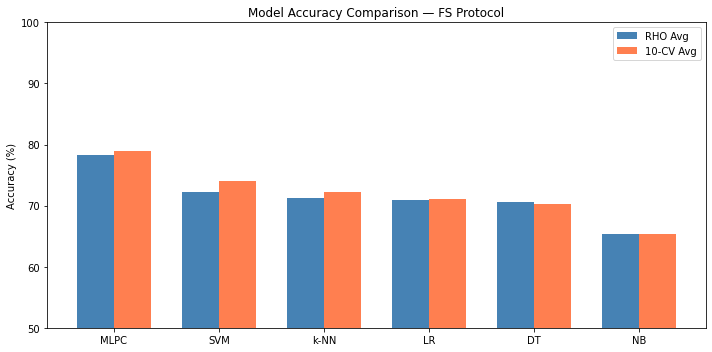

In [14]:
# Results Comparison Table
print("\n===== SUMMARY TABLE (FS Protocol) =====")
summary = pd.DataFrame({
    'Model': list(rho_results.keys()),
    'RHO Avg (%)': [rho_results[m]['Avg'] for m in rho_results],
    'RHO Max (%)': [rho_results[m]['Max'] for m in rho_results],
    'RHO Std':     [rho_results[m]['Std'] for m in rho_results],
    '10CV Avg (%)': [cv_results[m]['Avg'] for m in cv_results],
    '10CV Max (%)': [cv_results[m]['Max'] for m in cv_results],
}).sort_values('RHO Avg (%)', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

# Bar chart comparison
plt.figure(figsize=(10, 5))
x = np.arange(len(summary))
width = 0.35
plt.bar(x - width/2, summary['RHO Avg (%)'],  width, label='RHO Avg',  color='steelblue')
plt.bar(x + width/2, summary['10CV Avg (%)'], width, label='10-CV Avg', color='coral')
plt.xticks(x, summary['Model'])
plt.ylim(50, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison — FS Protocol')
plt.legend()
plt.tight_layout()
plt.show()

MLPC Accuracy: 81.25 %

Classification Report:
              precision    recall  f1-score   support

    Low (-1)       0.72      1.00      0.84        13
  Middle (0)       0.83      0.71      0.77        21
   High (+1)       0.92      0.79      0.85        14

    accuracy                           0.81        48
   macro avg       0.82      0.83      0.82        48
weighted avg       0.83      0.81      0.81        48



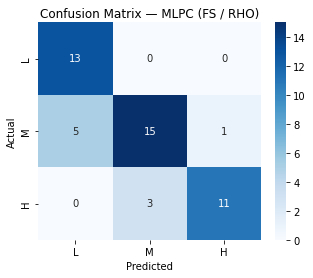

In [15]:
#  Confusion Matrix for Best Model (MLPC)
from sklearn.model_selection import train_test_split

X_np = X_FS.values
y_np = y.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_np, test_size=0.1, stratify=y_np, random_state=42
)

best_model = MLPClassifier(
    hidden_layer_sizes=(128,64,32,16,8),
    activation='relu', batch_size=100,
    learning_rate_init=0.0001, max_iter=1000, random_state=42
)
best_model.fit(X_tr, y_tr)
y_pred = best_model.predict(X_te)

print("MLPC Accuracy:", accuracy_score(y_te, y_pred)*100, "%")
print("\nClassification Report:")
print(classification_report(y_te, y_pred, target_names=['Low (-1)','Middle (0)','High (+1)']))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['L','M','H'],
            yticklabels=['L','M','H'])
plt.title('Confusion Matrix — MLPC (FS / RHO)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

  0%|          | 0/48 [00:00<?, ?it/s]

Using SHAP values of shape: (48, 12)
X_te shape: (48, 12)


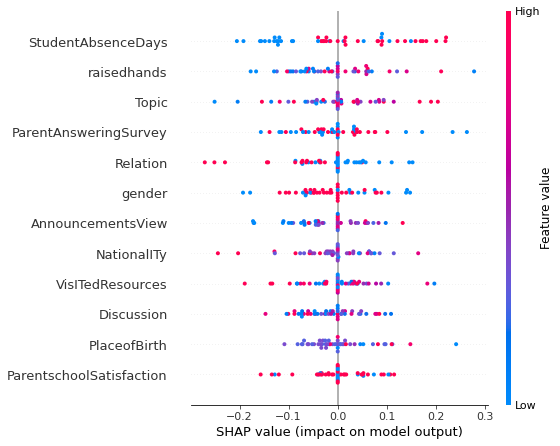

In [17]:
# SHAP Explainability — Safe Version
explainer   = shap.KernelExplainer(best_model.predict_proba, shap.sample(X_tr, 50))
shap_values = explainer.shap_values(X_te, nsamples=100)

# Auto-detect correct format
if isinstance(shap_values, list):
    # Multi-class: shap_values is a list of arrays, one per class
    # Pick class with most samples (index 1 = Middle class 'M')
    sv = shap_values[1]
elif len(shap_values.shape) == 3:
    # 3D array (samples x features x classes) — take one class slice
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

print("Using SHAP values of shape:", sv.shape)
print("X_te shape:", X_te.shape)

shap.summary_plot(
    sv,
    X_te,
    feature_names=X_FS.columns.tolist(),
    plot_type='dot',
    show=True
)